# ---RFA Segmentation---

rfm_segment
Potential Loyalists    210
Loyal Customers        165
At Risk                158
Lost                   113
New Customers           74
Champions               73
Name: count, dtype: int64

                     customers  avg_recency  avg_frequency  avg_monetary  \
rfm_segment                                                                
Loyal Customers            165         39.5            8.0        3700.6   
At Risk                    158        180.7            8.1        3802.8   
Potential Loyalists        210        141.5            4.6        2583.0   
Champions                   73         17.2            9.7        3989.6   
New Customers               74         16.1            4.6        1916.0   
Lost                       113        442.2            3.6         976.3   

                     total_revenue  
rfm_segment                         
Loyal Customers           610590.8  
At Risk                   600839.0  
Potential Loyalists       542429.3  
Champ

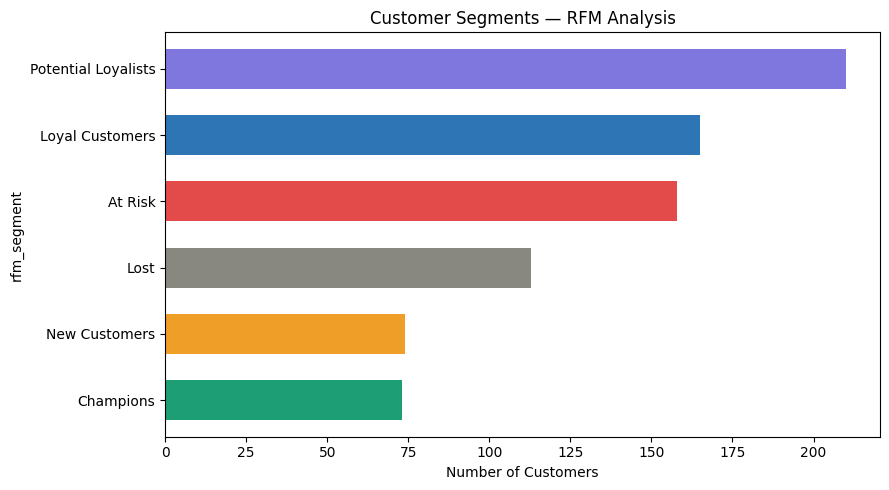

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Load data ──────────────────────────────────────────────────
df = pd.read_csv('data/superstore.csv', encoding='latin1')
df.columns = df.columns.str.lower().str.replace(' ', '_')
df['order_date'] = pd.to_datetime(df['order_date'])

snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

# ── Raw RFM metrics per customer ───────────────────────────────
rfm = df.groupby(['customer_id', 'customer_name', 'segment']).agg(
    recency   = ('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id',   'nunique'),
    monetary  = ('sales',      'sum')
).reset_index()

# ── Score 1–4 (4 = best) ───────────────────────────────────────
rfm['r_score'] = pd.qcut(rfm['recency'],
                          4, labels=[4, 3, 2, 1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          4, labels=[1, 2, 3, 4])
rfm['m_score'] = pd.qcut(rfm['monetary'],
                          4, labels=[1, 2, 3, 4])

# ── Segment function (uses R, F and M) ────────────────────────
def assign_segment(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    m = int(row['m_score'])

    if r >= 4 and f >= 4:              return 'Champions'
    if r >= 3 and f >= 3:              return 'Loyal Customers'
    if r >= 4 and f <= 2:              return 'New Customers'
    if r <= 2 and f >= 3:              return 'At Risk'
    if r <= 1 and m <= 2:              return 'Lost'
    return 'Potential Loyalists'

rfm['rfm_segment'] = rfm.apply(assign_segment, axis=1)

# ── Summary table ──────────────────────────────────────────────
summary = rfm.groupby('rfm_segment').agg(
    customers  = ('customer_id',  'count'),
    avg_recency   = ('recency',   'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary  = ('monetary',  'mean'),
    total_revenue = ('monetary',  'sum')
).round(1).sort_values('total_revenue', ascending=False)

print(rfm['rfm_segment'].value_counts())
print()
print(summary)

# ── Save output ────────────────────────────────────────────────
rfm.to_csv('data/rfm_segments.csv', index=False)
print("\nSaved: data/rfm_segments.csv")

# ── Chart ──────────────────────────────────────────────────────
colors = {
    'Champions':           '#1D9E75',
    'Loyal Customers':     '#2E75B6',
    'Potential Loyalists': '#7F77DD',
    'New Customers':       '#EF9F27',
    'At Risk':             '#E24B4A',
    'Lost':                '#888780'
}

counts = rfm['rfm_segment'].value_counts()
bar_colors = [colors[s] for s in counts.index]

counts.plot(kind='barh', figsize=(9, 5), color=bar_colors, width=0.6)
plt.xlabel('Number of Customers')
plt.title('Customer Segments — RFM Analysis')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('dashboard/screenshots/chart_rfm_segments.png', dpi=150)
plt.show()